# Análise dos resultados da heurística gulosa determinística

Resultados em `deterministic-results-greedy/` no padrão:
`experiment-preproc-{use_preprocessing}`

Instâncias determinísticas: `instances/cases-alto-santo`, `instances/cases-limoeiro`

Objetivos:
1. Avaliar quantos blocos o greedy atende e % de cobertura
2. Analisar LB (valor da solução heurística), Route_Time e Attend_Time
3. Comparar por cidade e tamanho do mapa
4. Exportar resultados para LaTeX

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["axes.grid"] = True
matplotlib.rcParams["grid.alpha"] = 0.3

import analysis_utils
import importlib
importlib.reload(analysis_utils)

from analysis_utils import (
    parse_experiment_folder_greedy,
    parse_experiment_name_greedy,
    export_greedy_to_latex,
    instance_sort_key,
    load_all_instance_data,
    parse_graph_file,
)

BASE_GREEDY = Path("deterministic-results-greedy")
INSTANCE_FOLDERS_DET = ["instances/cases-alto-santo", "instances/cases-limoeiro"]
if not BASE_GREEDY.exists():
    raise FileNotFoundError(f"Pasta {BASE_GREEDY} não encontrada.")

In [2]:
# Carregar resultados
raw = parse_experiment_folder_greedy(BASE_GREEDY)
records = [r for _, r in raw]
df_all = pd.DataFrame(records)

params = [parse_experiment_name_greedy(r["experiment"]) for _, r in raw]
if params:
    for k in params[0].keys():
        df_all[k] = [p.get(k) for p in params]

df_all = df_all.sort_values("instance_name", key=lambda c: c.map(instance_sort_key)).reset_index(drop=True)

# Carregar dados de input para cruzamento
inst_data_det = {}
for folder in INSTANCE_FOLDERS_DET:
    fp = Path(folder)
    if not fp.is_dir():
        continue
    for f in sorted(fp.glob("*.txt")):
        inst_data_det[f.stem] = parse_graph_file(f)

print(f"Total de resultados: {len(df_all)}")
print(f"Experimentos: {df_all['experiment'].nunique()}")
print(f"Instâncias de input carregadas: {len(inst_data_det)}")
df_all.head()

Total de resultados: 39
Experimentos: 1
Instâncias de input carregadas: 39


,instance_name,attended_blocks,N,M,B,LB,Runtime,Route_Time,Attend_Time,att_pct,experiment,use_preprocessing
0,alto-santo-1000-1,19,100,304,19,39.0,0.0,94.0,604.0,100.000000,experiment-preproc-1,1
1,alto-santo-1000-2,38,127,388,45,238.0,0.0,124.0,1071.0,84.444444,experiment-preproc-1,1
2,alto-santo-1000-3,38,127,388,45,245.0,0.0,124.0,1071.0,84.444444,experiment-preproc-1,1
3,alto-santo-1000-4,38,127,388,45,252.0,0.0,124.0,1071.0,84.444444,experiment-preproc-1,1
4,alto-santo-1000-5,38,127,388,45,268.0,0.0,124.0,1071.0,84.444444,experiment-preproc-1,1


## 1. Visão geral: blocos atendidos e cobertura

In [3]:
# Enriquecer com dados de input
df_input = pd.DataFrame([
    {"instance_name": name, "B_total": info["B"], "total_cases": info["total_cases"],
     "blocks_with_cases": info["blocks_with_cases"]}
    for name, info in inst_data_det.items()
])
df = df_all.merge(df_input, on="instance_name", how="left", suffixes=("", "_input"))
df["att_pct_total"] = 100.0 * df["attended_blocks"] / df["B"]

# Extrair cidade e tamanho
df["city"] = df["instance_name"].apply(lambda x: "-".join(x.split("-")[:-2]))
df["map_size"] = df["instance_name"].apply(lambda x: int(x.split("-")[-2]) if x.split("-")[-2].isdigit() else 0)

print(f"Blocos atendidos: min={df['attended_blocks'].min()}, max={df['attended_blocks'].max()}, média={df['attended_blocks'].mean():.1f}")
print(f"% cobertura: min={df['att_pct_total'].min():.1f}%, max={df['att_pct_total'].max():.1f}%, média={df['att_pct_total'].mean():.1f}%")
print(f"LB (solução): min={df['LB'].min()}, max={df['LB'].max()}, média={df['LB'].mean():.1f}")

Blocos atendidos: min=19, max=39, média=32.4
% cobertura: min=7.9%, max=100.0%, média=51.8%
LB (solução): min=39.0, max=495.0, média=216.8


In [4]:
# Tabela resumo por instância
summary = df[["instance_name", "N", "M", "B", "attended_blocks", "att_pct_total",
              "LB", "Route_Time", "Attend_Time", "Runtime"]].copy()
summary = summary.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
summary

,instance_name,N,M,B,attended_blocks,att_pct_total,LB,Route_Time,Attend_Time,Runtime
0,alto-santo-1000-1,100,304,19,19,100.000000,39.0,94.0,604.0,0.0
1,alto-santo-1000-2,127,388,45,38,84.444444,238.0,124.0,1071.0,0.0
2,alto-santo-1000-3,127,388,45,38,84.444444,245.0,124.0,1071.0,0.0
3,alto-santo-1000-4,127,388,45,38,84.444444,252.0,124.0,1071.0,0.0
4,alto-santo-1000-5,127,388,45,38,84.444444,268.0,124.0,1071.0,0.0
5,alto-santo-1000-6,130,400,49,38,77.551020,319.0,125.0,1069.0,0.0
6,alto-santo-2000-1,100,304,19,19,100.000000,39.0,94.0,604.0,0.0
7,alto-santo-2000-2,159,480,47,34,72.340426,247.0,83.0,1115.0,0.0
8,alto-santo-2000-3,159,480,47,32,68.085106,251.0,106.0,1089.0,0.0
9,alto-santo-2000-4,159,480,47,32,68.085106,258.0,106.0,1089.0,0.0


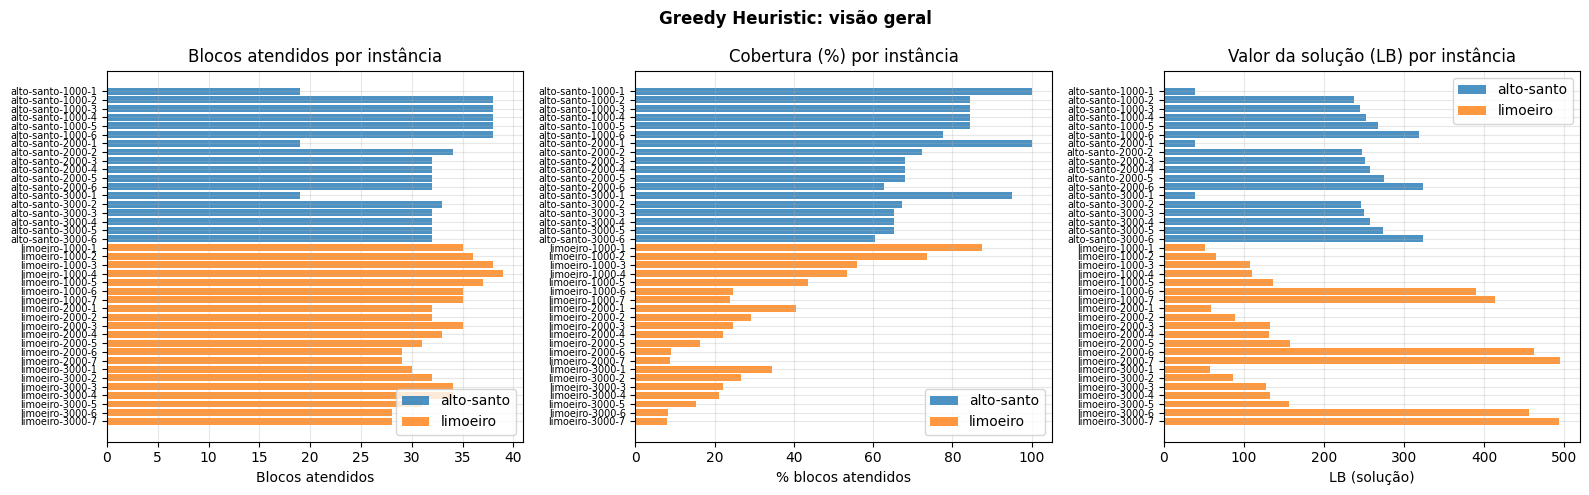

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Blocos atendidos por instância (barras agrupadas por cidade)
for city, color in [("alto-santo", "C0"), ("limoeiro", "C1")]:
    sub = df[df["city"] == city].sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    axes[0].barh(sub["instance_name"], sub["attended_blocks"], color=color, alpha=0.8, label=city)
axes[0].set_xlabel("Blocos atendidos")
axes[0].set_title("Blocos atendidos por instância")
axes[0].legend()
axes[0].invert_yaxis()
axes[0].tick_params(axis="y", labelsize=7)

# % cobertura por instância
for city, color in [("alto-santo", "C0"), ("limoeiro", "C1")]:
    sub = df[df["city"] == city].sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    axes[1].barh(sub["instance_name"], sub["att_pct_total"], color=color, alpha=0.8, label=city)
axes[1].set_xlabel("% blocos atendidos")
axes[1].set_title("Cobertura (%) por instância")
axes[1].legend()
axes[1].invert_yaxis()
axes[1].tick_params(axis="y", labelsize=7)

# LB por instância
for city, color in [("alto-santo", "C0"), ("limoeiro", "C1")]:
    sub = df[df["city"] == city].sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    axes[2].barh(sub["instance_name"], sub["LB"], color=color, alpha=0.8, label=city)
axes[2].set_xlabel("LB (solução)")
axes[2].set_title("Valor da solução (LB) por instância")
axes[2].legend()
axes[2].invert_yaxis()
axes[2].tick_params(axis="y", labelsize=7)

plt.suptitle("Greedy Heuristic: visão geral", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Comparação por cidade e tamanho do mapa

In [6]:
agg = df.groupby(["city", "map_size"]).agg(
    LB_medio=("LB", "mean"),
    att_blocks_medio=("attended_blocks", "mean"),
    att_pct_medio=("att_pct_total", "mean"),
    B_medio=("B", "mean"),
    route_time_medio=("Route_Time", "mean"),
    attend_time_medio=("Attend_Time", "mean"),
    n=("instance_name", "count"),
).reset_index()
agg

,city,map_size,LB_medio,att_blocks_medio,att_pct_medio,B_medio,route_time_medio,attend_time_medio,n
0,alto-santo,1000,226.833333,34.833333,85.888133,41.333333,119.166667,992.833333,6
1,alto-santo,2000,232.333333,30.166667,73.223474,43.000000,102.333333,1011.000000,6
2,alto-santo,3000,231.666667,30.000000,69.773777,44.833333,111.000000,1003.666667,6
3,limoeiro,1000,182.142857,36.428571,51.775186,86.142857,263.714286,923.714286,7
4,limoeiro,2000,217.857143,31.571429,21.485801,189.714286,418.142857,752.285714,7
5,limoeiro,3000,215.571429,31.000000,19.381858,203.571429,447.857143,731.857143,7


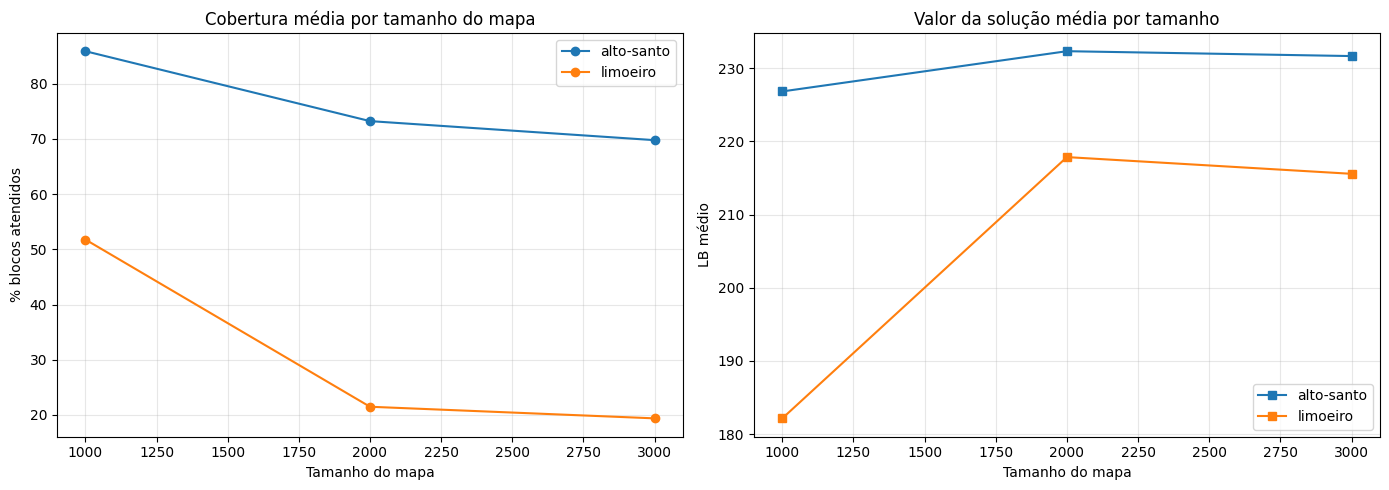

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for city in df["city"].unique():
    sub = agg[agg["city"] == city].sort_values("map_size")
    axes[0].plot(sub["map_size"], sub["att_pct_medio"], "o-", label=city)
    axes[1].plot(sub["map_size"], sub["LB_medio"], "s-", label=city)

axes[0].set_xlabel("Tamanho do mapa")
axes[0].set_ylabel("% blocos atendidos")
axes[0].set_title("Cobertura média por tamanho do mapa")
axes[0].legend()

axes[1].set_xlabel("Tamanho do mapa")
axes[1].set_ylabel("LB médio")
axes[1].set_title("Valor da solução média por tamanho")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Exportação LaTeX

In [8]:
OUT_LATEX = Path("latex-tables-greedy")
OUT_LATEX.mkdir(parents=True, exist_ok=True)

for exp_name in sorted(df_all["experiment"].unique()):
    df_exp = df_all[df_all["experiment"] == exp_name].copy()
    df_exp = df_exp.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))

    prep = exp_name.replace("experiment-preproc-", "")
    caption = f"Results of the Greedy Heuristic (preprocessing={prep})."
    label = f"tab:greedy-prep{prep}"
    latex = export_greedy_to_latex(df_exp, caption=caption, label=label)
    fname = f"table-{exp_name}.tex"
    (OUT_LATEX / fname).write_text(latex, encoding="utf-8")
    print(f"Exportado: {OUT_LATEX / fname}")
    print(latex[:600])
    print("...")

Exportado: latex-tables-greedy/table-experiment-preproc-1.tex
\begin{table}[ht!]
\centering
\caption{Results of the Greedy Heuristic (preprocessing=1).}
\label{tab:greedy-prep1}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrr}
\toprule
\multicolumn{1}{c}{\textbf{Instance}} & \multicolumn{1}{c}{\textbf{|V|}} & \multicolumn{1}{c}{\textbf{|A|}} & \multicolumn{1}{c}{\textbf{|B|}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Attended\\ Blocks\end{tabular}}} & \multicolumn{1}{c}{\textbf{LB}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Route\\ Time\end{tabular}}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Exec.\\ Time (s
...
